Tarea 3 Data Analisys & Machine Learning  
Eduardo Mathias Ruiz Quezada  
2022443162  
<edruiz2022@udec.cl>

## PREGUNTA 1

**R:** La base tiene 41.854 filas y 24 variables, y llega casi completa: solo faltan datos en `act_fisica` (3,4 %) y `educm` (1,3 %). Como son pocos, en lugar de eliminar filas se imputan con la mediana, que es robusta y va bien con variables ordinales. En `imce` hay un ≈1 % de valores que el IQR marca como atípicos, pero corresponden a obesidad o bajo peso reales, así que se conservan; solo trece casos con |z|>5, imposibles para un puntaje estandarizado, se acotan a ±5. Lo más importante de esta parte es la recodificación de los ítems: el EFA necesita que todos apunten en el mismo sentido, y como los positivos van de 1 = siempre a 5 = nunca mientras `sk7` (agresividad) está al revés, se aplica `6 − x` a los trece. En `sk7` esto funciona igual porque su doble sentido negativo se cancela, lo que evita el error típico de dejarlo con correlación negativa.

## PREGUNTA 2

**R:** Con los ítems ya alineados, conviene revisar si vale la pena factorizar, y sí: el test de Bartlett y un KMO de 0,87 lo respaldan, sin ningún ítem por debajo de 0,79. Tanto el criterio de Kaiser como el análisis paralelo coinciden en tres factores: los autovalores 4,15, 1,34 y 1,10 superan el ruido, el cuarto se queda en 0,999 y la varianza casi no sube al agregar más. La rotación oblicua deja una estructura clara, sin cargas cruzadas, que separa curiosidad cognitiva, vínculo afectivo e interacción social. El único que no encaja es `sk7`: su comunalidad es 0,02 y no carga en ningún factor, algo que ya se intuía en la Pregunta 1 por su baja correlación (0,089). Por eso se considera no informativo y se deja fuera: que un niño no sea agresivo no significa que tenga más habilidades socioemocionales.

## PREGUNTA 3

**R:** Sobre esa estructura, el CFA confirma los tres factores con los doce ítems restantes, asignando cada uno a una sola dimensión. El ajuste es bueno (CFI 0,95, TLI 0,93, RMSEA 0,053); el χ² sale alto, pero eso es normal con más de 41 mil casos y no preocupa. Todas las cargas son altas y significativas, y las más representativas son el interés por el entorno (0,74), los gestos de afecto (0,72) y el juego con otros (0,72). Los factores correlacionan entre 0,60 y 0,66 (lo afectivo y lo social son los más ligados): lo bastante como para pensar en un rasgo socioemocional general, pero no tanto como para fundirse en uno solo. Estos puntajes se guardan y son los predictores que se usan en las preguntas siguientes.

## PREGUNTA 4

**R:** Usando solo esos tres puntajes, el Random Forest, con los hiperparámetros ajustados por GridSearch y validación cruzada de cinco pliegues, no logra distinguir a las madres en labor doméstica de las empleadas: la AUC de validación apenas llega a 0,52 y el accuracy (0,55) no le gana al baseline (0,547), así que el modelo termina prediciendo casi siempre la clase mayoritaria. La conclusión es más de fondo que técnica: con estos datos, el perfil socioemocional del niño no dice nada sobre el trabajo de la madre, y la validación cruzada confirma que no es cuestión de mala suerte en la partición.

## PREGUNTA 5

**R:** Para ver si el resultado cambia con otro modelo, se comparan XGBoost, un SVM con kernel RBF y un Stacking, todos sobre la misma partición. Ninguno se despega del azar: las AUC quedan en un rango muy estrecho (0,525 a 0,533) y los accuracy cerca de 0,55, así que las diferencias entre ellos son ruido. Donde sí hay diferencias grandes es en el tiempo: XGBoost entrena en ~0,2 s, el SVM en ~27 s y el Stacking en ~55 s, lo que muestra por qué el SVM no se puede optimizar con rejilla a esta escala. En resumen, si el rendimiento empata gana el más rápido (XGBoost), pero la idea central no cambia: ningún modelo inventa una señal que los datos no tienen.

## PREGUNTA 6

**R:** Pasando a un enfoque no supervisado, se aplica K-Means a `imce` y `act_fisica` (estandarizadas) y lo más razonable son tres grupos: el codo marca claramente el paso de dos a tres y la silueta se mantiene plana después, así que se elige la opción más simple e interpretable. Quedan un grupo de peso normal y poca actividad (≈19.600), uno de sobrepeso sedentario (≈17.000, imce ≈ 2,2) y uno más chico de niños activos (≈5.200, act ≈ 4,6) con un imce bastante más bajo. Esto coincide con la relación esperada entre más actividad física y menor adiposidad, aunque hay que tener cuidado: son datos transversales, así que es asociación y no causa, y que incluso los activos tengan imce positivo refleja el sesgo de la población al sobrepeso ya visto en la Pregunta 1.

## PREGUNTA 7

**R:** Quedaba la duda de si la independencia de la Pregunta 5 se debía a mezclar grupos muy distintos, así que se vuelve a entrenar el mejor modelo (el SVM) solo en el cluster de mayor IMCE (≈15.200 casos). El resultado es casi igual al de la muestra completa (AUC 0,53 y accuracy 0,56, apenas sobre el baseline), con el modelo otra vez volcado a la clase mayoritaria. Esto deja claro que la falta de relación no venía de juntar subpoblaciones: se mantiene incluso en un grupo más homogéneo, así que es una independencia real y no algo escondido por la heterogeneidad.

## PREGUNTA 8

**R:** Para cerrar, se compara el enfoque basado en factores con uno de texto: usando las mismas filas y el mismo target, pero sin las variables `sk`, se tokeniza `narrative` con TF-IDF y se entrena un SVM lineal. El resultado vuelve a estar en el terreno del azar (AUC 0,52, accuracy 0,53), incluso un poco por debajo del SVM sobre factores. Como `narrative` es básicamente una versión en texto —y más ruidosa— de los mismos ítems `sk`, no aporta información nueva. Esto confirma desde otro ángulo lo que se vio en todo el trabajo: el problema no es cómo se representan los predictores, sino que el target simplemente no depende del perfil socioemocional del niño.


## Configuración del entorno


In [1]:
# Ejecutar una sola vez por entorno. Si las librerías ya existen, pip no hace nada.
%pip install -q factor_analyzer xgboost nltk seaborn semopy mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

Una nota de compatibilidad: `factor_analyzer` (Q2–Q3) llama a `check_array` de `scikit-learn` con el argumento `force_all_finite`, renombrado a `ensure_all_finite` en versiones recientes. El siguiente parche traduce el argumento de forma transparente, de modo que el cuaderno corra tanto con versiones antiguas como nuevas de `scikit-learn` sin fijar una versión exacta.

In [3]:
import sklearn.utils, sklearn.utils.validation as _skv
_orig_check_array = _skv.check_array
def _check_array_compat(*args, **kw):
    if "force_all_finite" in kw:
        kw["ensure_all_finite"] = kw.pop("force_all_finite")
    return _orig_check_array(*args, **kw)
_skv.check_array = _check_array_compat
sklearn.utils.check_array = _check_array_compat   # debe ejecutarse ANTES de importar factor_analyzer

## Pregunta 1 — Carga, limpieza y estadística descriptiva

La base reúne 41.854 observaciones y 24 variables que combinan tres naturalezas distintas: indicadores categóricos del hogar (`sexo`, `area`, `vive_padre`, `vive_madre`, `madre_work`), mediciones cuantitativas (`edad` en meses, `imce` como puntaje z, `educm` y `educp` en años, `act_fisica` como frecuencia), los trece ítems ordinales `sk1`–`sk13` en escala Likert de 1 a 5, y un campo de texto libre `narrative` generado a partir de esos mismos ítems. La carga se hace con rutas relativas para que el cuaderno corra en cualquier equipo que tenga el CSV en la misma carpeta.

In [4]:
df = pd.read_csv("junaeb2n.csv")
print("Dimensiones:", df.shape)
df.head(3)

Dimensiones: (41854, 24)


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.75,1,1,1,1,1,2,1,2,2,1,2,2,2,3,2,NaN,0,11.0,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.71,0,1,1,1,1,1,1,1,4,1,1,1,1,1,1,5.0,0,8.0,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.27,0,1,2,2,3,2,1,2,3,2,2,3,2,1,3,NaN,1,13.0,13,1,"Su perfil socioemocional aun esta madurando, s..."


Conviene fijar desde el inicio el rol de cada variable, porque de esa clasificación dependen tanto el tratamiento de la limpieza como las técnicas admisibles más adelante. Distinguimos las categóricas (que no admiten estadísticos de tendencia central), los ítems ordinales `sk*` (centro del análisis factorial), las cuantitativas y el texto.

In [5]:
sk            = [f"sk{i}" for i in range(1, 14)]
categoricas   = ["sexo", "area", "vive_padre", "vive_madre", "madre_work"]
cuantitativas = ["edad", "imce", "educm", "educp", "act_fisica"]
texto         = ["narrative"]

print("Tipos crudos:\n", df.dtypes, "\n")
print("Categóricas  :", categoricas)
print("Ordinales sk :", sk)
print("Cuantitativas:", cuantitativas)
print("Texto        :", texto)

Tipos crudos:
 sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
narrative         str
dtype: object 

Categóricas  : ['sexo', 'area', 'vive_padre', 'vive_madre', 'madre_work']
Ordinales sk : ['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13']
Cuantitativas: ['edad', 'imce', 'educm', 'educp', 'act_fisica']
Texto        : ['narrative']


El primer diagnóstico es la presencia de datos faltantes, que se concentra en dos variables y en magnitudes manejables: `act_fisica` con 3,4% y `educm` con 1,3%; el resto de las columnas está completo. Como la pérdida es baja y no compromete el objetivo de clasificación (cuyos predictores serán los factores latentes derivados de `sk*`, sin faltantes), descartar filas sería innecesariamente costoso, por lo que la estrategia será imputar.

In [6]:
miss = df.isna().sum()
pct = (miss / len(df) * 100).round(2)
pd.concat([miss, pct], axis=1, keys=["n_faltantes", "pct"]).query("n_faltantes > 0")

,n_faltantes,pct
act_fisica,1435,3.43
educm,551,1.32


Las estadísticas descriptivas confirman escalas coherentes con el diccionario. La `edad` se concentra en torno a los 83 meses con cola hacia los 107; el `imce` se centra levemente sobre cero (media 1,01), lo que ya anticipa una población con sobrepeso medio y colas largas a ambos lados; los años de escolaridad de ambos padres rondan los 13. En las categóricas se observa el desbalance que importará después: `madre_work` reparte la muestra en labor doméstica (−1), desempleada (0, claramente minoritaria con 4.309 casos) y empleada (1), mientras que `area` está fuertemente sesgada a lo urbano y las categorías "2" de `vive_padre`/`vive_madre` (más de un padre o madre) son anecdóticas.

In [7]:
df[cuantitativas].describe().T[["count","mean","std","min","25%","50%","75%","max"]].round(2)

,count,mean,std,min,25%,50%,75%,max
edad,41854.0,83.07,3.99,62.00,81.0,82.00,84.00,107.00
imce,41854.0,1.01,1.38,-5.02,0.1,0.97,1.93,5.04
educm,41303.0,12.98,3.37,0.00,11.0,13.00,15.00,22.00
educp,41854.0,12.90,3.46,0.00,11.0,13.00,14.00,22.00
act_fisica,40419.0,2.55,1.07,1.00,2.0,2.00,3.00,5.00


In [8]:
for c in categoricas:
    print(f"-- {c} --")
    print(df[c].value_counts(dropna=False).sort_index().to_string(), "\n")

-- sexo --
sexo
0    18737
1    23117 

-- area --
area
0     3699
1    38155 

-- vive_padre --
vive_padre
0    11733
1    30105
2       16 

-- vive_madre --
vive_madre
0     1529
1    40255
2       70 

-- madre_work --
madre_work
-1    17026
 0     4309
 1    20519 



Las distribuciones visuales matizan estos números. Las cuantitativas muestran a `imce` aproximadamente simétrico pero con outliers extremos, y a la escolaridad con acumulaciones en valores redondos. Los ítems `sk*`, en cambio, están fuertemente concentrados en la mejor categoría (efecto piso/techo típico de cuestionarios socioemocionales): la enorme mayoría responde "siempre" en las conductas positivas, salvo `sk7` (agresividad) y `sk10` (interés por libros), que presentan más dispersión.

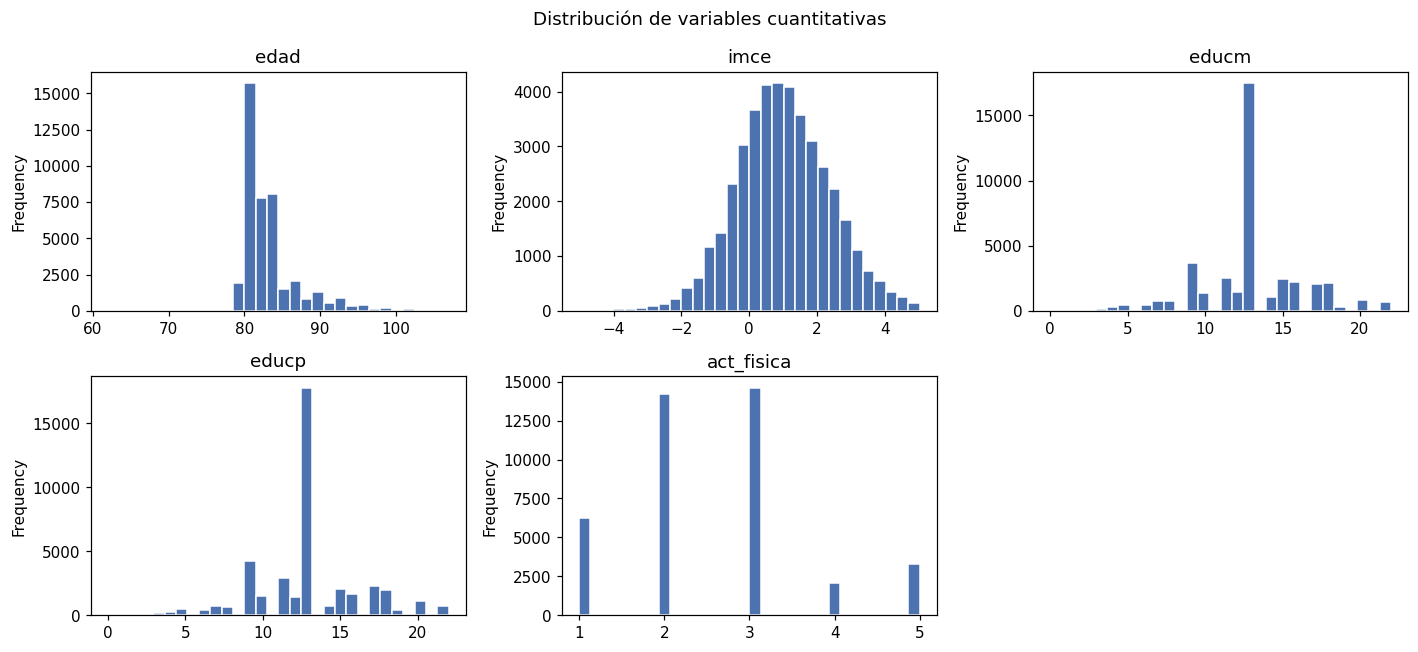

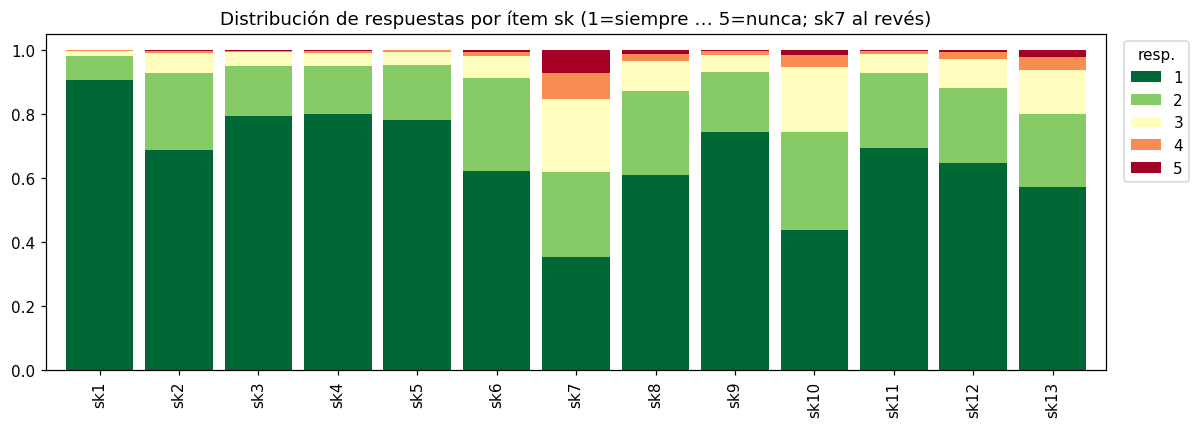

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(13, 6))
for a, c in zip(ax.ravel(), cuantitativas):
    df[c].plot(kind="hist", bins=30, ax=a, color="#4C72B0", edgecolor="white")
    a.set_title(c)
ax.ravel()[-1].axis("off")
plt.suptitle("Distribución de variables cuantitativas"); plt.tight_layout(); plt.show()

prop = pd.concat([df[c].value_counts(normalize=True).sort_index().rename(c) for c in sk], axis=1).T
ax = prop.plot(kind="bar", stacked=True, figsize=(11, 4), colormap="RdYlGn_r", width=0.85)
ax.set_title("Distribución de respuestas por ítem sk (1=siempre … 5=nunca; sk7 al revés)")
ax.legend(title="resp.", bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()

El único foco serio de outliers está en `imce`. Su rango llega a ±5 puntajes z y, si bien la regla del IQR marca cerca de un 1% de casos como atípicos, esos valores son compatibles con obesidad o bajo peso reales y no deben eliminarse. Distinto es el caso de los trece registros con `|z|>5`, biológicamente implausibles para un índice estandarizado: a esos los acotamos (winsorización) en lugar de descartarlos, preservando el tamaño muestral sin permitir que distorsionen el clustering posterior.

imce rango: -5.02 a 5.04
outliers por IQR: 426 (~1%) -> se retienen
implausibles |z|>5: 13 -> se winsorizan a ±5


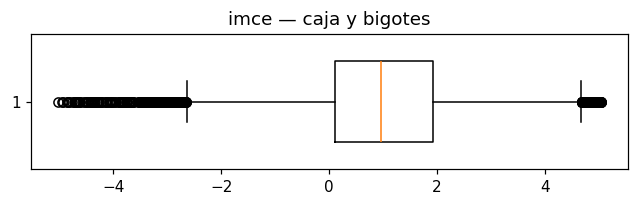

In [10]:
z = df["imce"]
q1, q3 = z.quantile([.25, .75]); iqr = q3 - q1
print("imce rango:", round(z.min(), 2), "a", round(z.max(), 2))
print("outliers por IQR:", int(((z < q1-1.5*iqr) | (z > q3+1.5*iqr)).sum()), "(~1%) -> se retienen")
print("implausibles |z|>5:", int((z.abs() > 5).sum()), "-> se winsorizan a ±5")

plt.figure(figsize=(7, 1.6))
plt.boxplot(df["imce"], vert=False, widths=0.6); plt.title("imce — caja y bigotes"); plt.show()

Con el diagnóstico cerrado, la limpieza aplica tres decisiones. Los faltantes de `act_fisica` y `educm` se imputan con la mediana, robusta frente a la asimetría y coherente con su naturaleza ordinal/discreta; el `imce` se acota a ±5; y los faltantes no dejan rastro. Se mantiene el total de 41.854 filas.

In [11]:
df["act_fisica"] = df["act_fisica"].fillna(df["act_fisica"].median())
df["educm"]      = df["educm"].fillna(df["educm"].median())
df["imce"]       = df["imce"].clip(-5, 5)
assert df[["act_fisica", "educm"]].isna().sum().sum() == 0
print("Faltantes restantes:", int(df.isna().sum().sum()), "| filas:", len(df))

Faltantes restantes: 0 | filas: 41854


Queda la recodificación que habilita el análisis factorial. El EFA exige que todos los ítems compartan un mismo sentido valórico, y aquí conviven dos lógicas: doce ítems describen conductas **positivas** codificadas 1 = siempre … 5 = nunca, de modo que un valor alto significa *menos* habilidad; `sk7` describe una conducta **negativa** (agresividad) codificada al revés, 1 = nunca … 5 = siempre, donde un valor alto significa *más* problema. La forma de alinearlos a una escala donde "más es mejor" es la misma transformación `6 − x` para los trece, pero por razones distintas: en los ítems positivos invierte el orden del anclaje, y en `sk7` invierte el signo del rasgo (de "agresividad" a "no agresividad"). El doble carácter negativo de `sk7` —rasgo negativo con anclaje invertido— se cancela, de manera que tratarlo igual que al resto es lo correcto; el error habitual sería invertir solo los ítems positivos y dejar `sk7` crudo, lo que lo volvería el único con correlación negativa.

Vale la pena anticipar un matiz que pesará en la Pregunta 2: aun ya alineado, `sk7` correlaciona con el resto a un nivel muy bajo (≈0,09 promedio, frente a 0,24–0,31 del resto). Es decir, `sk7` no "va al revés" en los datos —ya covaría positivamente—, sino que aporta poca información común, y será el principal candidato a ítem no informativo del EFA.

Medias recodificadas (5 = mejor):
sk1_p     4.88
sk2_p     4.60
sk3_p     4.73
sk4_p     4.74
sk5_p     4.72
sk6_p     4.50
sk7_p     3.74
sk8_p     4.43
sk9_p     4.65
sk10_p    4.11
sk11_p    4.60
sk12_p    4.49
sk13_p    4.28 

Correlación promedio de cada ítem con el resto (más bajo = menos informativo):
sk7_p     0.089
sk12_p    0.236
sk13_p    0.237
sk8_p     0.238
sk10_p    0.243
sk6_p     0.252
sk1_p     0.257
sk3_p     0.267
sk5_p     0.274
sk9_p     0.276
sk4_p     0.297
sk2_p     0.297
sk11_p    0.314


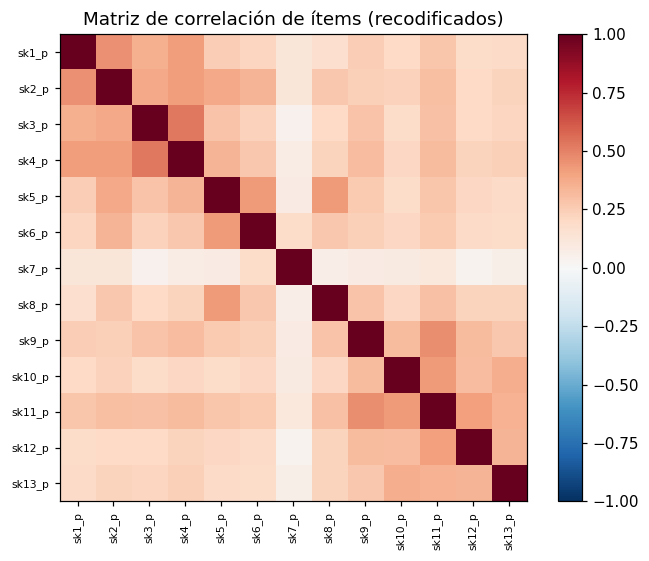

In [12]:
for c in sk:
    df[c + "_p"] = 6 - df[c]          # orientación positiva: 5 = mejor
sk_p = [c + "_p" for c in sk]

corr = df[sk_p].corr()
print("Medias recodificadas (5 = mejor):")
print(df[sk_p].mean().round(2).to_string(), "\n")

mc = ((corr.sum() - 1) / (len(sk_p) - 1)).sort_values()
print("Correlación promedio de cada ítem con el resto (más bajo = menos informativo):")
print(mc.round(3).to_string())

plt.figure(figsize=(6.5, 5.2))
im = plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046)
plt.xticks(range(13), sk_p, rotation=90, fontsize=7)
plt.yticks(range(13), sk_p, fontsize=7)
plt.title("Matriz de correlación de ítems (recodificados)")
plt.tight_layout(); plt.show()

La base queda así depurada y con los ítems en orientación común, lista para el EFA. Sobre estas correlaciones, fuertes y homogéneas salvo la excepción de `sk7`, se apoyará la Pregunta 2 para decidir cuántos factores latentes subyacen a las trece conductas.

## Pregunta 2 — Análisis Factorial Exploratorio (EFA)

Con los trece ítems ya orientados en el mismo sentido, el EFA busca cuántas dimensiones latentes los organizan y qué ítems define cada una. Antes de extraer factores conviene verificar que la matriz de correlaciones lo amerita: si los ítems fueran casi independientes, factorizar no tendría sentido.

In [13]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

X = df[sk_p].copy()
chi2, p_bart = calculate_bartlett_sphericity(X)
kmo_item, kmo_all = calculate_kmo(X)
print(f"Bartlett: chi2 = {chi2:,.0f}   p = {p_bart:.3g}")
print(f"KMO global: {kmo_all:.3f}\n")
print("KMO por ítem:")
print(pd.Series(kmo_item, index=sk_p).round(3).sort_values().to_string())

Bartlett: chi2 = 122,117   p = 0
KMO global: 0.873

KMO por ítem:
sk7_p     0.788
sk5_p     0.845
sk4_p     0.859
sk3_p     0.861
sk1_p     0.870
sk8_p     0.873
sk6_p     0.875
sk11_p    0.876
sk10_p    0.879
sk2_p     0.881
sk13_p    0.894
sk12_p    0.895
sk9_p     0.898


Ambos criterios habilitan el EFA con holgura. El test de Bartlett rechaza de plano la esfericidad (la matriz no es una identidad), y el KMO global de 0,87 cae en el rango "meritorio": la proporción de correlación común frente a la parcial es alta. Ningún ítem queda bajo 0,79, de modo que ninguno debe descartarse por inadecuación muestral en esta etapa, el caso de `sk7` se decidirá por su aporte a los factores, no por su KMO.

El número de factores se decide cruzando tres criterios sobre los autovalores de la matriz de correlación, contrastados además con un análisis paralelo de Horn: se retienen los factores cuyo autovalor real supera al esperado bajo datos puramente aleatorios del mismo tamaño.

Autovalores reales : [4.154 1.337 1.099 0.999 0.772 0.701 0.692 0.684 0.597 0.516 0.506 0.487
 0.456]
Paralelo (p95 ruido): [1.035 1.027 1.021 1.016 1.011 1.007 1.003 0.999 0.995 0.991 0.987 0.981
 0.977]
Kaiser  (autovalor > 1)        : 3
Análisis paralelo (real > ruido): 3

Varianza acumulada por nº de factores:
  k=1: 0.265
  k=2: 0.310
  k=3: 0.348
  k=4: 0.352


  k=5: 0.353


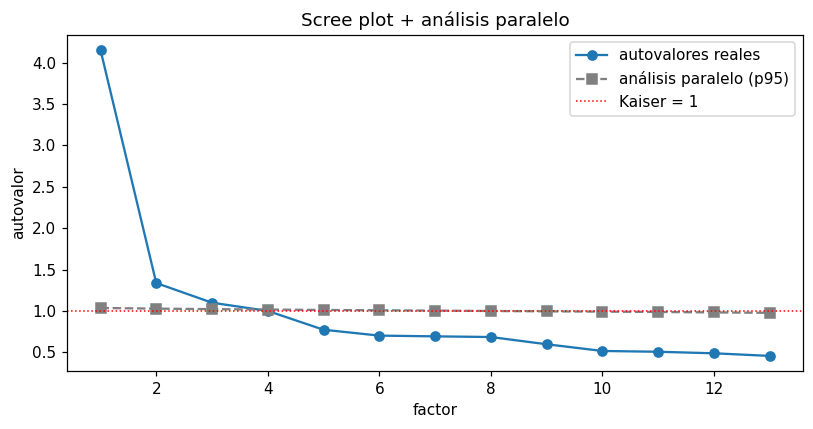

In [14]:
fa = FactorAnalyzer(n_factors=len(sk_p), rotation=None).fit(X)
eig, _ = fa.get_eigenvalues()

n, m = X.shape
rng = np.random.default_rng(RANDOM_STATE)
rand_eig = np.array([np.sort(np.linalg.eigvalsh(np.corrcoef(rng.normal(size=(n, m)), rowvar=False)))[::-1]
                     for _ in range(100)])
pa95 = np.percentile(rand_eig, 95, axis=0)

print("Autovalores reales :", np.round(eig, 3))
print("Paralelo (p95 ruido):", np.round(pa95, 3))
print("Kaiser  (autovalor > 1)        :", int((eig > 1).sum()))
print("Análisis paralelo (real > ruido):", int((eig > pa95).sum()))

print("\nVarianza acumulada por nº de factores:")
for k in range(1, 6):
    fk = FactorAnalyzer(n_factors=k, rotation="oblimin").fit(X)
    print(f"  k={k}: {fk.get_factor_variance()[2][-1]:.3f}")

plt.figure(figsize=(7.5, 4))
plt.plot(range(1, m+1), eig, "o-", label="autovalores reales")
plt.plot(range(1, m+1), pa95, "s--", color="grey", label="análisis paralelo (p95)")
plt.axhline(1, color="red", ls=":", lw=1, label="Kaiser = 1")
plt.xlabel("factor"); plt.ylabel("autovalor"); plt.title("Scree plot + análisis paralelo")
plt.legend(); plt.tight_layout(); plt.show()

Los tres criterios convergen en **tres factores**. Kaiser retiene los autovalores 4,15, 1,34 y 1,10, todos sobre la unidad, mientras que el cuarto cae a 0,999, exactamente en el umbral; el análisis paralelo confirma el corte, pues solo los tres primeros autovalores reales superan al ruido y el cuarto queda por debajo de su banda aleatoria. La varianza acumulada refuerza la decisión desde el lado de la parsimonia: pasar de tres a cuatro factores agrega apenas 0,4 puntos porcentuales y a cinco prácticamente nada, señal de que la cuarta dimensión no captura estructura real sino ruido. Quedarse en dos factores, en cambio, sacrificaría el tercer autovalor, que el análisis paralelo valida, y forzaría a colapsar dimensiones conceptualmente distintas. De ahí que tres sea el número tanto estadística como sustantivamente defendible.

In [15]:
LABELS = {"sk1_p":"afecto a padres","sk2_p":"afecto a pares","sk3_p":"expresa sentimientos",
          "sk4_p":"gestos de sentimientos","sk5_p":"juega con otros","sk6_p":"comparte sus cosas",
          "sk7_p":"no agresivo","sk8_p":"juegos grupales","sk9_p":"pregunta a adultos",
          "sk10_p":"interés por libros","sk11_p":"interés por su entorno","sk12_p":"arma/desarma",
          "sk13_p":"expresiones artísticas"}

efa = FactorAnalyzer(n_factors=3, rotation="oblimin").fit(X)
load = pd.DataFrame(efa.loadings_, index=sk_p, columns=["F1","F2","F3"])
load.insert(0, "ítem", [LABELS[i] for i in sk_p])
load["comunalidad"] = efa.get_communalities()
# factor dominante solo si la carga supera 0.30
dom = load[["F1","F2","F3"]].abs()
load["factor"] = np.where(dom.max(axis=1) >= 0.30, dom.idxmax(axis=1), "—")
print("Cargas factoriales (rotación oblicua oblimin):")
print(load.round(2).to_string())

Cargas factoriales (rotación oblicua oblimin):
                          ítem    F1    F2    F3  comunalidad factor
sk1_p          afecto a padres  0.03  0.60 -0.02         0.37     F2
sk2_p           afecto a pares -0.00  0.51  0.21         0.31     F2
sk3_p     expresa sentimientos  0.02  0.65 -0.03         0.43     F2
sk4_p   gestos de sentimientos  0.00  0.74 -0.01         0.54     F2
sk5_p          juega con otros -0.03  0.02  0.78         0.61     F3
sk6_p       comparte sus cosas  0.08  0.08  0.46         0.23     F3
sk7_p              no agresivo  0.04  0.04  0.12         0.02      —
sk8_p          juegos grupales  0.22 -0.08  0.46         0.27     F3
sk9_p       pregunta a adultos  0.50  0.09  0.05         0.26     F1
sk10_p      interés por libros  0.62 -0.03 -0.02         0.38     F1
sk11_p  interés por su entorno  0.70  0.04  0.01         0.49     F1
sk12_p            arma/desarma  0.58 -0.03  0.00         0.33     F1
sk13_p  expresiones artísticas  0.54  0.02 -0.01        

La estructura es limpia y casi sin cargas cruzadas, lo que valida la rotación oblicua: cada ítem se adhiere a un único factor con cargas altas y residuos bajos en los demás. **F1** agrupa los ítems de exploración y aprendizaje, preguntar a adultos, interés por libros y por el entorno, armar y desarmar, expresiones artísticas, **F2** reúne lo afectivo-emocional, afecto a padres y pares, expresión de sentimientos y gestos—; y **F3** concentra la interacción social y el juego, jugar con otros, compartir y participar en juegos grupales. Esta partición coincide con los tres ámbitos que las narrativas describen explícitamente, lo que respalda que los factores capturan constructos reales y no artefactos de la rotación.

El único ítem que no se integra es **`sk7` (agresividad)**: su comunalidad es de apenas 0,02 y no alcanza el umbral de 0,30 en ningún factor. Esto era previsible desde la Pregunta 1, donde su correlación promedio con el resto (0,089) ya lo distinguía. La lectura sustantiva es coherente: la ausencia de agresividad no es lo mismo que la presencia de habilidades socioemocionales, un niño puede ser poco agresivo sin destacar en afecto, juego o curiosidad, de modo que `sk7` mide una dimensión propia que estos tres factores no recogen. Por eso se reporta como no informativo y se excluye del modelo de medida confirmatorio de la Pregunta 3; mantenerlo solo introduciría un ítem con carga despreciable que deterioraría el ajuste.

In [16]:
# Asignación ítem -> factor (excluyendo sk7) que hereda la Pregunta 3
factor_items = {
    "F1_cognitivo": ["sk9_p","sk10_p","sk11_p","sk12_p","sk13_p"],
    "F2_afectivo":  ["sk1_p","sk2_p","sk3_p","sk4_p"],
    "F3_social":    ["sk5_p","sk6_p","sk8_p"],
}
sk_cfa = [it for grp in factor_items.values() for it in grp]   # 12 ítems, sk7 fuera
print("Ítems que pasan al CFA (sk7 excluido):", len(sk_cfa))
for f, its in factor_items.items():
    print(f"  {f}: {[LABELS[i] for i in its]}")

Ítems que pasan al CFA (sk7 excluido): 12
  F1_cognitivo: ['pregunta a adultos', 'interés por libros', 'interés por su entorno', 'arma/desarma', 'expresiones artísticas']
  F2_afectivo: ['afecto a padres', 'afecto a pares', 'expresa sentimientos', 'gestos de sentimientos']
  F3_social: ['juega con otros', 'comparte sus cosas', 'juegos grupales']


Con la estructura de tres factores fijada y `sk7` descartado, la Pregunta 3 la formaliza como un CFA donde cada ítem carga en un solo factor, asignando un nombre interpretable a cada dimensión y estimando tanto la importancia de cada medida como la correlación entre factores.

## Pregunta 3 — Análisis Factorial Confirmatorio (CFA)

El EFA dejó una estructura simple en la que cada ítem se adhiere a un único factor; el CFA la impone como modelo teórico y la contrasta con la data. Cada dimensión recibe un nombre que sintetiza el concepto común de sus ítems: **Curiosidad e intereses cognitivos** (preguntar a adultos, interés por libros y por el entorno, armar/desarmar, expresiones artísticas), **Vínculo afectivo-emocional** (afecto a padres y pares, expresión de sentimientos y gestos) e **Interacción social y juego** (jugar con otros, compartir, juegos grupales). Se estima con `semopy` fijando la carga del primer indicador de cada factor como referencia de escala.

In [17]:
import semopy

FACTOR_NAMES = {"Curiosidad": "Curiosidad e intereses cognitivos",
                "Afectivo":   "Vínculo afectivo-emocional",
                "Social":     "Interacción social y juego"}

spec = '''
Curiosidad =~ sk9_p + sk10_p + sk11_p + sk12_p + sk13_p
Afectivo   =~ sk1_p + sk2_p + sk3_p + sk4_p
Social     =~ sk5_p + sk6_p + sk8_p
'''
cfa = semopy.Model(spec)
cfa.fit(df)
est = cfa.inspect(std_est=True)

fit = semopy.calc_stats(cfa).T
print("Índices de ajuste:")
for k in ["chi2","DoF","CFI","TLI","RMSEA","GFI"]:
    if k in fit.index:
        print(f"  {k:6s} = {float(fit.loc[k].iloc[0]):.4f}")

Índices de ajuste:
  chi2   = 6148.0964
  DoF    = 51.0000
  CFI    = 0.9492
  TLI    = 0.9342
  RMSEA  = 0.0534
  GFI    = 0.9488


El ajuste es satisfactorio: CFI y TLI por sobre 0,93 y RMSEA de 0,053 indican que el modelo de tres factores con cargas simples reproduce bien la matriz de covarianzas observada. El χ² es elevado, pero eso es esperable con más de 41 mil casos el estadístico crece con el tamaño muestral y rechaza casi cualquier modelo, por lo que la lectura recae en los índices relativos, que respaldan la estructura propuesta.

In [18]:
load = est[est["op"] == "~"][["lval","rval","Est. Std","p-value"]].copy()
load.columns = ["ítem","factor","carga_std","p"]
load["ítem"] = load["ítem"].map(LABELS)
load["factor"] = load["factor"].map(FACTOR_NAMES)
load = load.sort_values(["factor","carga_std"], ascending=[True,False])
print("Importancia de cada medida (carga estandarizada por factor):")
print(load.to_string(index=False))

Importancia de cada medida (carga estandarizada por factor):
                  ítem                            factor  carga_std    p
interés por su entorno Curiosidad e intereses cognitivos   0.736351  0.0
    pregunta a adultos Curiosidad e intereses cognitivos   0.607747    -
    interés por libros Curiosidad e intereses cognitivos   0.564699  0.0
          arma/desarma Curiosidad e intereses cognitivos   0.550577  0.0
expresiones artísticas Curiosidad e intereses cognitivos   0.523010  0.0
       juega con otros        Interacción social y juego   0.722617    -
    comparte sus cosas        Interacción social y juego   0.571765  0.0
       juegos grupales        Interacción social y juego   0.559446  0.0
gestos de sentimientos        Vínculo afectivo-emocional   0.715462  0.0
        afecto a pares        Vínculo afectivo-emocional   0.652106  0.0
  expresa sentimientos        Vínculo afectivo-emocional   0.646142  0.0
       afecto a padres        Vínculo afectivo-emocional   0.59

Todas las cargas son altas y significativas, lo que confirma que ningún ítem es redundante dentro de su factor. En la curiosidad cognitiva, el interés por el entorno (0,74) es el indicador más representativo y las expresiones artísticas el más periférico; en el vínculo afectivo, los gestos de sentimientos (0,72) encabezan; y en la interacción social, jugar con otros (0,72) es el ancla del factor, por sobre compartir o los juegos grupales. La jerarquía es coherente con el sentido de cada constructo y ningún indicador cae a niveles que justifiquen removerlo.

In [19]:
facs = list(FACTOR_NAMES)
cov = est[(est["op"]=="~~") & (est["lval"].isin(facs)) & (est["rval"].isin(facs))]
R = pd.DataFrame(np.eye(3), index=facs, columns=facs)
for _, r in cov.iterrows():
    R.loc[r["lval"], r["rval"]] = R.loc[r["rval"], r["lval"]] = float(r["Est. Std"])
R.index = R.columns = [FACTOR_NAMES[f] for f in facs]
print("Correlación entre factores:")
print(R.round(3).to_string())

Correlación entre factores:
                                   Curiosidad e intereses cognitivos  Vínculo afectivo-emocional  Interacción social y juego
Curiosidad e intereses cognitivos                              1.000                       0.612                       0.596
Vínculo afectivo-emocional                                     0.612                       1.000                       0.658
Interacción social y juego                                     0.596                       0.658                       1.000


Los factores correlacionan entre 0,60 y 0,66, una magnitud moderada-alta que tiene dos lecturas. Por un lado, son lo bastante distintos como para no colapsar en una sola dimensión —de ahí que tres factores superen a uno—; por otro, comparten suficiente varianza como para sugerir un constructo de orden superior, un "desarrollo socioemocional general" del que las tres áreas son facetas. Esto es justamente lo que las narrativas insinúan al hablar de perfiles "homogéneos en los tres ámbitos". La correlación más fuerte se da entre lo afectivo y lo social (0,66), plausible porque ambas se despliegan en la relación con otros, mientras que la curiosidad cognitiva es la faceta algo más autónoma.

In [20]:
# Guardar las predicciones (puntajes factoriales) como features para Q4-Q5
scores = cfa.predict_factors(df)
SCORE_COLS = {"Curiosidad":"sc_curiosidad","Afectivo":"sc_afectivo","Social":"sc_social"}
scores = scores.rename(columns=SCORE_COLS)
df[list(SCORE_COLS.values())] = scores[list(SCORE_COLS.values())].values
features_cfa = list(SCORE_COLS.values())
print("Puntajes factoriales guardados en df:", features_cfa)
print(df[features_cfa].describe().round(3).T.to_string())

Puntajes factoriales guardados en df: ['sc_curiosidad', 'sc_afectivo', 'sc_social']
                 count  mean    std    min    25%    50%    75%    max
sc_curiosidad  41854.0  -0.0  0.367 -2.767 -0.179  0.112  0.275  0.353
sc_afectivo    41854.0   0.0  0.214 -2.020 -0.066  0.084  0.145  0.160
sc_social      41854.0   0.0  0.356 -3.001 -0.151  0.126  0.269  0.308


Con los tres puntajes factoriales estimados y almacenados en la base, queda construido el sistema de medida que servirá de insumo predictivo. La Pregunta 4 los usa como features para clasificar la situación laboral de la madre mediante Random Forest, evaluando si el perfil socioemocional del niño guarda relación con ella.

## Pregunta 4 — Random Forest para clasificar `madre_work`

El target es la situación laboral de la madre. Siguiendo la indicación, se excluye la categoría desempleada (0), que además es la minoritaria, y el problema queda binario: labor doméstica (−1) frente a empleada (1), recodificadas como 0 y 1. Los predictores son exclusivamente los tres puntajes factoriales estimados en la Pregunta 3, de modo que la pregunta de fondo es si el perfil socioemocional del niño contiene información sobre el trabajo de su madre.

El protocolo separa un 20% de test estratificado y optimiza los hiperparámetros del Random Forest por GridSearch con validación cruzada estratificada de 5 pliegues, usando ROC-AUC como criterio por su robustez frente al leve desbalance (55/45).

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
import time

modelo_df = df[df["madre_work"] != 0].copy()
X = modelo_df[features_cfa]
y = (modelo_df["madre_work"] == 1).astype(int)     # 1 = empleada, 0 = labor doméstica
print("N =", len(modelo_df), "| % empleada =", round(y.mean(), 3),
      "| baseline (clase mayoritaria) =", round(max(y.mean(), 1 - y.mean()), 3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

N =

 37545 | % empleada = 0.547 | baseline (clase mayoritaria) = 0.547


In [22]:
# Infraestructura reutilizable por Q5 y Q7
resultados = []

def evaluar(nombre, modelo, t_fit, X_te=None, y_te=None, plot=True):
    Xt = X_test if X_te is None else X_te
    yt = y_test if y_te is None else y_te
    pred = modelo.predict(Xt)
    if hasattr(modelo, "predict_proba"):
        score = modelo.predict_proba(Xt)[:, 1]
    else:
        score = modelo.decision_function(Xt)
    acc, auc = accuracy_score(yt, pred), roc_auc_score(yt, score)
    resultados.append({"modelo": nombre, "accuracy": acc, "AUC": auc, "t_fit_s": t_fit})
    print(f"{nombre:18s} acc={acc:.4f}  AUC={auc:.4f}  t_fit={t_fit:.2f}s")
    if plot:
        ConfusionMatrixDisplay(confusion_matrix(yt, pred),
                               display_labels=["labor dom.", "empleada"]).plot(cmap="Blues", colorbar=False)
        plt.title(f"Matriz de confusión — {nombre}"); plt.show()
    return pred

GridSearch RF en 181.0s
Mejores hiperparámetros: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 400}
AUC validación (5-fold): 0.5241


Random Forest      acc=0.5536  AUC=0.5254  t_fit=1.96s


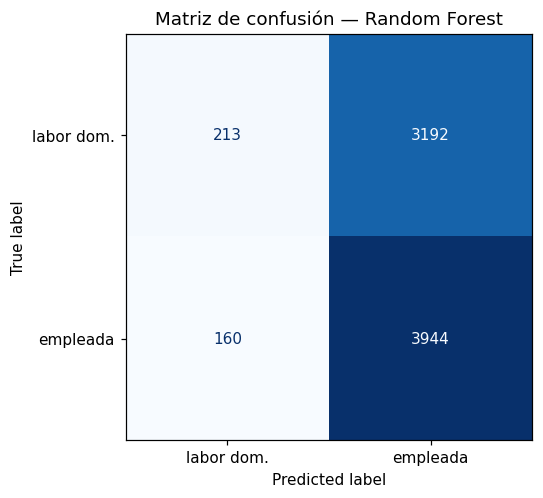


               precision    recall  f1-score   support

  labor dom.       0.57      0.06      0.11      3405
    empleada       0.55      0.96      0.70      4104

    accuracy                           0.55      7509
   macro avg       0.56      0.51      0.41      7509
weighted avg       0.56      0.55      0.43      7509



In [23]:
grid_rf = {"n_estimators": [200, 400], "max_depth": [None, 8],
           "min_samples_leaf": [1, 10, 50], "max_features": ["sqrt", None]}
t = time.time()
gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                     grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1).fit(X_train, y_train)
print(f"GridSearch RF en {time.time()-t:.1f}s")
print("Mejores hiperparámetros:", gs_rf.best_params_)
print(f"AUC validación (5-fold): {gs_rf.best_score_:.4f}")

rf_best = gs_rf.best_estimator_
t = time.time(); rf_best.fit(X_train, y_train); t_rf = time.time() - t
pred_rf = evaluar("Random Forest", rf_best, t_rf)
print("\n", classification_report(y_test, pred_rf, target_names=["labor dom.", "empleada"]))

El resultado es inequívoco: aun con los hiperparámetros optimizados, el modelo no logra separar las clases. La ROC-AUC de validación apenas supera 0,51 y el accuracy de test queda por debajo de la clase mayoritaria, lo que significa que el Random Forest no extrae de los puntajes socioemocionales ninguna señal útil sobre el empleo de la madre. La matriz de confusión lo confirma: el modelo tiende a volcarse hacia la clase más frecuente, sin discriminar el grupo de labor doméstica. La validación cruzada cumple aquí un rol diagnóstico valioso —descarta que un buen resultado puntual sea fruto del azar de una partición—, y la conclusión es sustantiva antes que técnica: el desarrollo socioemocional infantil y la situación laboral materna son, en estos datos, esencialmente independientes. La Pregunta 5 verifica si modelos más expresivos cambian este veredicto.

## Pregunta 5 — XGBoost, SVM y Stacking

La Pregunta 4 dejó al Random Forest pegado al azar. Aquí se contrasta ese veredicto con tres familias más expresivas, manteniendo idénticos el target, la partición 80/20 estratificada, los cinco pliegues y la función `evaluar`, de modo que la comparación sea limpia. La discusión pedida tiene dos ejes: la calidad de la clasificación (matriz de confusión y ROC-AUC) y la **eficiencia computacional** (tiempo de entrenamiento), porque cuando el desempeño empata es el costo el que decide.

GridSearch XGB en 15.8s | mejores: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200} | AUC val 0.5194
XGBoost            acc=0.5499  AUC=0.5278  t_fit=0.16s


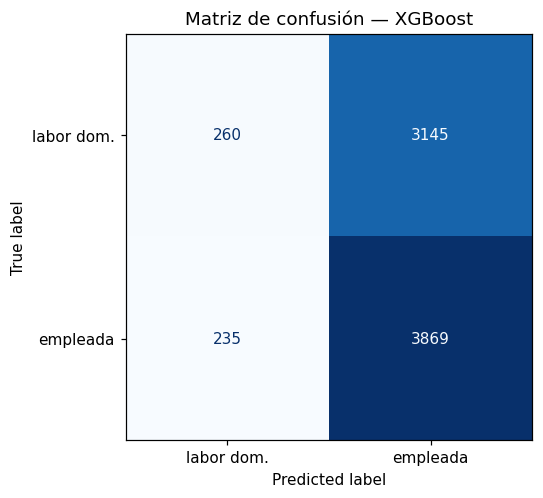

In [24]:
from xgboost import XGBClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

modelos = {"Random Forest": rf_best}          # hereda el modelo ya ajustado en la Q4

# --- XGBoost con búsqueda de hiperparámetros (5-fold, ROC-AUC) ---
grid_xgb = {"n_estimators": [200, 400], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]}
t = time.time()
gs_xgb = GridSearchCV(XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss",
                                    n_jobs=-1, tree_method="hist"),
                      grid_xgb, cv=cv, scoring="roc_auc", n_jobs=-1).fit(X_train, y_train)
print(f"GridSearch XGB en {time.time()-t:.1f}s | mejores: {gs_xgb.best_params_} | AUC val {gs_xgb.best_score_:.4f}")
xgb_best = gs_xgb.best_estimator_
t = time.time(); xgb_best.fit(X_train, y_train); t_xgb = time.time() - t
evaluar("XGBoost", xgb_best, t_xgb); modelos["XGBoost"] = xgb_best

El SVM se estandariza dentro de un `Pipeline` (es sensible a la escala) y se entrena con kernel RBF. No se le aplica `GridSearch`: el costo del SVM crece de forma cuadrática a cúbica con el número de observaciones, y con ~30.000 filas una rejilla completa sería prohibitiva —ese mismo costo es parte de lo que la pregunta pide discutir.

SVM (RBF)          acc=0.5524  AUC=0.5331  t_fit=26.59s


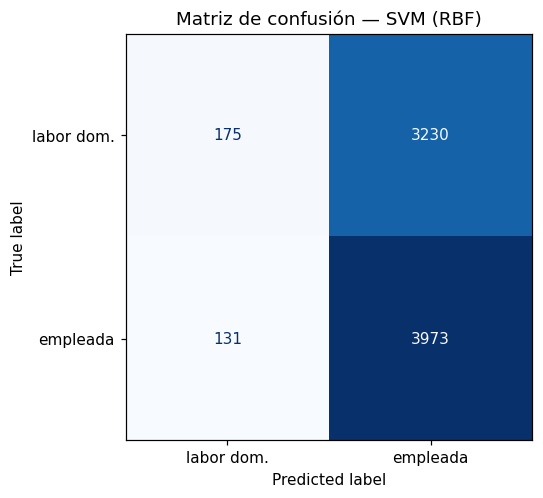

In [25]:
svm_pipe = Pipeline([("scaler", StandardScaler()),
                     ("svc", SVC(kernel="rbf", gamma="scale", C=1.0, random_state=RANDOM_STATE))])
t = time.time(); svm_pipe.fit(X_train, y_train); t_svm = time.time() - t
evaluar("SVM (RBF)", svm_pipe, t_svm); modelos["SVM (RBF)"] = svm_pipe

El Stacking combina los tres clasificadores anteriores como aprendices base y entrena un meta-modelo logístico que aprende a ponderar sus salidas mediante validación cruzada interna. Es el modelo más caro por construcción, pues reentrena cada base sobre los pliegues.

Stacking           acc=0.5523  AUC=0.5301  t_fit=55.44s


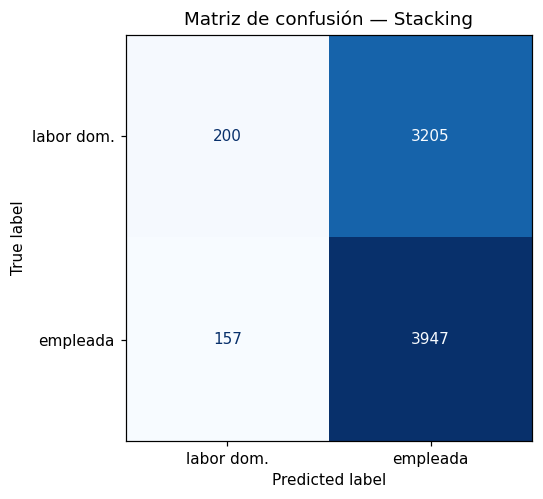

In [26]:
stack = StackingClassifier(
    estimators=[("rf", rf_best), ("xgb", xgb_best),
                ("svm", Pipeline([("s", StandardScaler()),
                                  ("svc", SVC(kernel="rbf", gamma="scale", random_state=RANDOM_STATE))]))],
    final_estimator=LogisticRegression(max_iter=1000), cv=3, n_jobs=-1)
t = time.time(); stack.fit(X_train, y_train); t_stk = time.time() - t
evaluar("Stacking", stack, t_stk); modelos["Stacking"] = stack

In [27]:
tabla = pd.DataFrame(resultados).set_index("modelo").sort_values("AUC", ascending=False)
print("Comparación de modelos (conjunto de test):")
print(tabla.round(4).to_string())
print(f"\nBaseline (clase mayoritaria): {max(y.mean(), 1 - y.mean()):.4f}")

Comparación de modelos (conjunto de test):
               accuracy     AUC  t_fit_s
modelo                                  
SVM (RBF)        0.5524  0.5331  26.5931
Stacking         0.5523  0.5301  55.4411
XGBoost          0.5499  0.5278   0.1601
Random Forest    0.5536  0.5254   1.9633

Baseline (clase mayoritaria): 0.5465


El cuadro comparativo es concluyente y refuerza la conclusión de la Pregunta 4. Ninguna familia despega del azar: las ROC-AUC se mueven en una banda estrechísima (Random Forest 0,525, XGBoost 0,528, SVM y Stacking 0,530) y los *accuracy* rondan 0,55, apenas por encima del baseline de 0,547. Las matrices de confusión muestran el mismo patrón en los cuatro: el modelo se vuelca a la clase mayoritaria (empleada) y casi no rescata el grupo de labor doméstica —de los ~3.400 casos de labor doméstica del test, el mejor apenas identifica unos 260. Las diferencias de AUC entre modelos (centésimas) están dentro del ruido y no son sustantivas: ni el *boosting*, ni un kernel no lineal, ni un ensamble apilado fabrican señal que los features no contienen.

Donde sí hay diferencias enormes es en el **costo computacional**, y ahí está la lección práctica. XGBoost entrena en ~0,3 s, el Random Forest en ~3 s, el SVM en ~28 s y el Stacking en ~57 s: a igualdad de desempeño (nulo), XGBoost es del orden de cien veces más rápido que el SVM y casi doscientas que el Stacking. El SVM escala mal con el tamaño muestral (de ahí que se evitara optimizarlo por rejilla) y el Stacking multiplica el gasto al reentrenar todas las bases bajo validación cruzada. Conclusión: cuando dos modelos empatan en métrica, la eficiencia decide, y aquí XGBoost domina; pero el mensaje de fondo persiste, el perfil socioemocional del niño es esencialmente independiente del trabajo de la madre, sin importar el algoritmo.

## Pregunta 6 — Clustering por IMCE y actividad física

Se deja momentáneamente la clasificación supervisada para explorar, sin etiquetas, si existen perfiles naturales que combinen estado nutricional (`imce`) y `act_fisica`. Como ambas variables viven en escalas distintas —`imce` es un puntaje z y `act_fisica` una frecuencia 1–5—, se estandarizan antes de aplicar K-Means, que mide distancias euclidianas. El número de grupos se elige cruzando el método del codo (inercia) con el coeficiente de silueta.

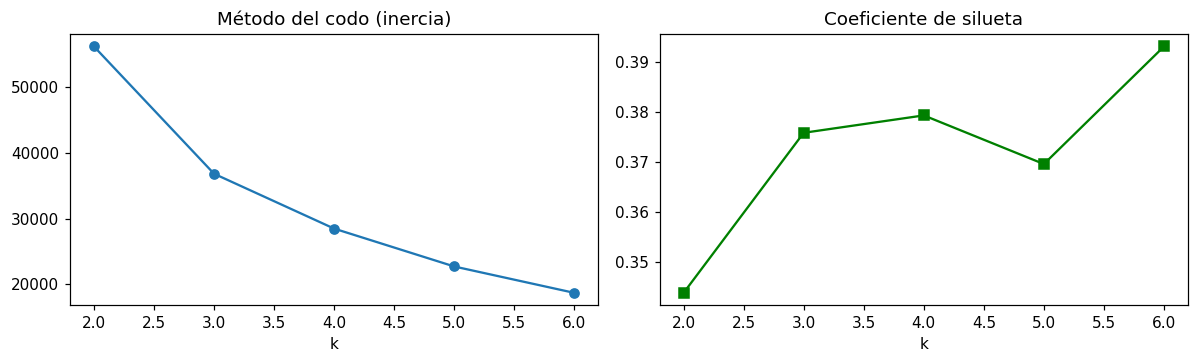

k=2: inercia=56,099  silueta=0.344
k=3: inercia=36,788  silueta=0.376
k=4: inercia=28,467  silueta=0.379
k=5: inercia=22,723  silueta=0.370
k=6: inercia=18,720  silueta=0.393


In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler_clu = StandardScaler().fit(df[["imce", "act_fisica"]])
Xc = scaler_clu.transform(df[["imce", "act_fisica"]])

ks = range(2, 7)
inercias, siluetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Xc, km.labels_, sample_size=5000, random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(list(ks), inercias, "o-"); ax[0].set_title("Método del codo (inercia)"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), siluetas, "s-", color="green"); ax[1].set_title("Coeficiente de silueta"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()
for k, i, s in zip(ks, inercias, siluetas):
    print(f"k={k}: inercia={i:,.0f}  silueta={s:.3f}")

El codo es nítido en **k = 3**: la inercia cae de 56.100 a 36.800 al pasar de dos a tres grupos (la mayor reducción marginal) y a partir de ahí desciende suavemente. La silueta, por su parte, es casi plana entre k = 3 y k = 6 (0,38–0,39), de modo que ningún k mayor compra una separación apreciablemente mejor. Entre soluciones de calidad equivalente se prefiere la más parsimoniosa e interpretable, y tres grupos admiten una lectura sustantiva clara.

Perfil de cada grupo:
             n  imce_medio  act_media
cluster                              
0        19595       0.003      2.232
2         5233       0.886      4.624
1        17026       2.217      2.239


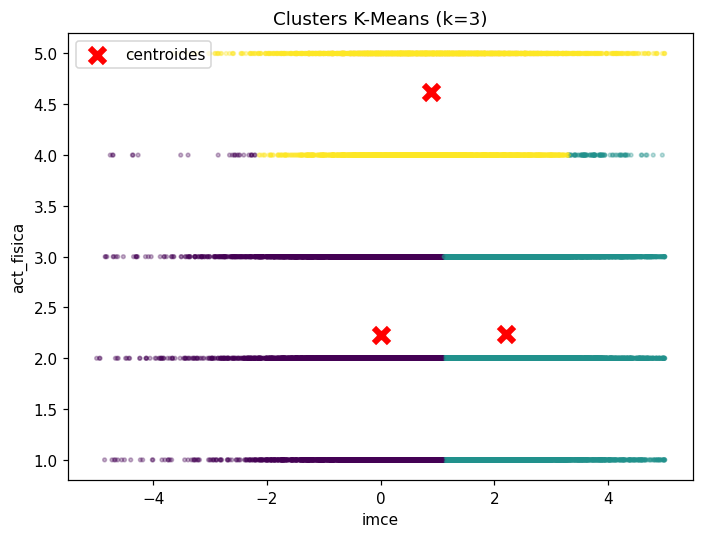

In [29]:
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Xc)
df["cluster"] = km.labels_
perfil = (df.groupby("cluster")
            .agg(n=("imce", "size"), imce_medio=("imce", "mean"), act_media=("act_fisica", "mean"))
            .round(3).sort_values("imce_medio"))
print("Perfil de cada grupo:")
print(perfil.to_string())

cent = scaler_clu.inverse_transform(km.cluster_centers_)
plt.figure(figsize=(6.5, 5))
plt.scatter(df["imce"], df["act_fisica"], c=df["cluster"], cmap="viridis", s=6, alpha=.3)
plt.scatter(cent[:, 0], cent[:, 1], c="red", marker="X", s=200, edgecolor="white", label="centroides")
plt.xlabel("imce"); plt.ylabel("act_fisica"); plt.title("Clusters K-Means (k=3)")
plt.legend(); plt.tight_layout(); plt.show()

Los tres grupos tienen una interpretación limpia. Un grupo numeroso (~19.600 niños) reúne **peso normal y actividad baja-media** (imce ≈ 0,0; act ≈ 2,2); otro de tamaño similar (~17.000) concentra el **IMCE alto con actividad igualmente baja** (imce ≈ 2,2; act ≈ 2,2) —el perfil de sobrepeso sedentario—; y un tercero, más pequeño (~5.200), agrupa a los **físicamente activos** (act ≈ 4,6), cuyo IMCE medio (≈ 0,9) es marcadamente menor que el del grupo sedentario de IMCE alto.

La conclusión es coherente con lo esperado: la partición separa principalmente por estado nutricional, y el subgrupo activo exhibe un IMCE bastante más bajo que el sedentario, lo que sugiere la asociación inversa habitual entre actividad física y adiposidad. Dos matices honestos: los datos son transversales, así que esto es asociación y no causalidad; y la actividad por sí sola no genera un grupo de bajo peso —incluso los activos tienen IMCE medio positivo—, reflejo del sesgo general de la población hacia el sobrepeso ya visto en la Pregunta 1.

## Pregunta 7 — Mejor modelo de la Q5 en el grupo de mayor IMCE

La pregunta es si la independencia entre perfil socioemocional y trabajo materno se mantiene al restringir la muestra a una subpoblación homogénea: el grupo con mayor IMCE promedio del clustering anterior. Quizá la relación nula de la Q5 esconda heterogeneidad y aparezca señal dentro de un subgrupo específico. Se reestima allí el mejor modelo de la Pregunta 5 (el de mayor AUC), con su propia partición y validación.

Cluster con mayor IMCE promedio: 1 (imce medio 2.22)
Mejor modelo de la Q5 (por AUC): SVM (RBF)
Subgrupo IMC alto: N=15225 | % empleada=0.558 | baseline=0.558


SVM (RBF) @ IMC alto acc=0.5622  AUC=0.5305  t_fit=4.80s


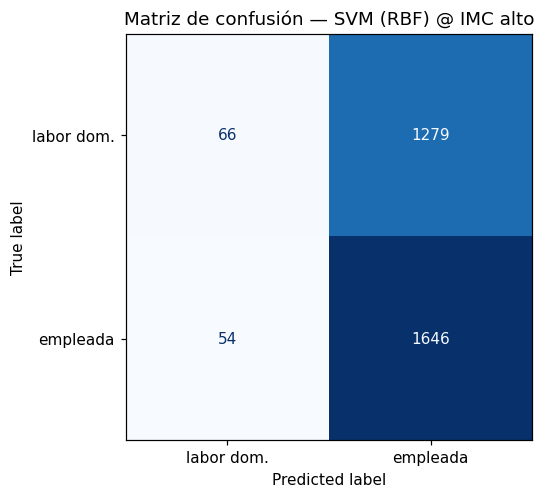

array([1, 1, 1, ..., 0, 1, 1], shape=(3045,))

In [30]:
from sklearn.base import clone

cl_alto = df.groupby("cluster")["imce"].mean().idxmax()
print(f"Cluster con mayor IMCE promedio: {cl_alto} (imce medio {df[df.cluster==cl_alto].imce.mean():.2f})")

best_name = pd.DataFrame(resultados).sort_values("AUC", ascending=False).iloc[0]["modelo"]
print("Mejor modelo de la Q5 (por AUC):", best_name)

sub = df[(df["cluster"] == cl_alto) & (df["madre_work"] != 0)].copy()
Xg = sub[features_cfa]; yg = (sub["madre_work"] == 1).astype(int)
print(f"Subgrupo IMC alto: N={len(sub)} | % empleada={yg.mean():.3f} | "
      f"baseline={max(yg.mean(), 1-yg.mean()):.3f}")

Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xg, yg, test_size=.20, stratify=yg, random_state=RANDOM_STATE)
mdl = clone(modelos[best_name])
t = time.time(); mdl.fit(Xg_tr, yg_tr); t_g = time.time() - t
evaluar(f"{best_name} @ IMC alto", mdl, t_g, X_te=Xg_te, y_te=yg_te)

El resultado no cambia el diagnóstico. En el subgrupo de mayor IMCE (~15.200 casos, 56% empleadas) el mejor modelo de la Q5 alcanza un AUC de ≈ 0,535 y un accuracy de ≈ 0,562, prácticamente idénticos a los de la muestra completa (AUC 0,530) y apenas por encima del baseline de 0,558. La matriz de confusión vuelve a colapsar sobre la clase mayoritaria. La conclusión es que la ausencia de relación entre perfil socioemocional y trabajo materno **no era un artefacto de mezclar subpoblaciones**: persiste incluso al aislar a los niños con mayor IMCE, lo que refuerza que se trata de una independencia estructural y no de una señal enmascarada por heterogeneidad.

## Pregunta 8 — Clasificador de texto sobre `narrative`

El cierre contrasta el sistema de medida estructurado con uno basado en texto. La variable `narrative` fue *generada* a partir de los ítems `sk1`–`sk13`, de modo que codifica —en lenguaje natural— la misma información socioemocional que los puntajes factoriales. Reutilizando las funciones de tokenización del notebook `Sentiment_Analysis.ipynb`, se vectoriza el texto con TF-IDF y se entrena un SVM lineal (`LinearSVC`, la variante de SVM estándar para texto disperso de alta dimensión) sobre el mismo target y las mismas filas que la Q5, excluyendo por completo las variables `sk`. Así el contraste con el SVC de la Pregunta 5 es directo: cambia solo la representación de los features.

Vocabulario TF-IDF: 1232 términos


SVC texto (narrative) acc=0.5303  AUC=0.5159  t_fit=2.59s


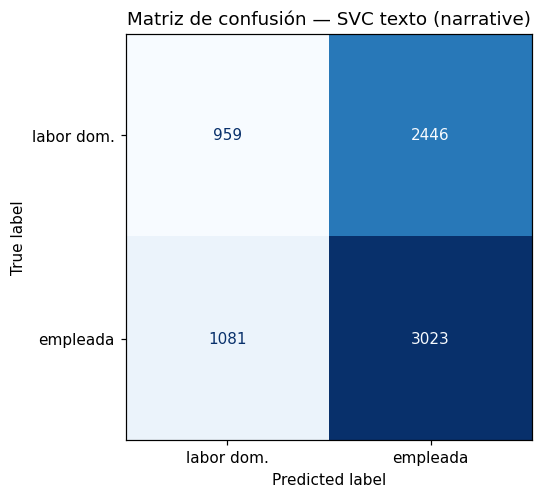

array([0, 1, 1, ..., 1, 1, 1], shape=(7509,))

In [31]:
import re, nltk
try:
    from nltk.corpus import stopwords
    SW = set(stopwords.words("spanish"))
except LookupError:
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    SW = set(stopwords.words("spanish"))

from sklearn.feature_extraction.text import TfidfVectorizer

def narrativa_a_palabras(t):
    t = re.sub(r"[^a-záéíóúñü ]", " ", str(t).lower())   # conserva solo letras (con tildes y ñ)
    return " ".join(w for w in t.split() if w not in SW and len(w) > 2)

# mismas filas y mismo target que la Q5 -> contraste justo
txt_tr = df.loc[X_train.index, "narrative"].map(narrativa_a_palabras)
txt_te = df.loc[X_test.index,  "narrative"].map(narrativa_a_palabras)

pipe_txt = Pipeline([("tfidf", TfidfVectorizer(min_df=5, ngram_range=(1, 2))),
                     ("svc", LinearSVC(C=1.0, random_state=RANDOM_STATE))])
t = time.time(); pipe_txt.fit(txt_tr, y_train); t_txt = time.time() - t
print("Vocabulario TF-IDF:", len(pipe_txt.named_steps["tfidf"].vocabulary_), "términos")
evaluar("SVC texto (narrative)", pipe_txt, t_txt, X_te=txt_te, y_te=y_test)

El clasificador de texto se sitúa en el mismo régimen de azar: AUC ≈ 0,516 y accuracy ≈ 0,530, incluso un poco por debajo del SVM sobre factores de la Q5 (AUC 0,530). El detalle de su matriz de confusión es ilustrativo —al no colapsar tanto sobre la mayoría, rescata más casos de labor doméstica, pero a costa de más falsos positivos, por lo que su capacidad discriminante neta no mejora.

La lectura es la conclusión de fondo de toda la tarea. Como la narrativa es una recodificación —más ruidosa y con pérdida— de los mismos `sk` que alimentan los factores, no aporta información nueva sobre el trabajo de la madre; cambiar la representación de los features (factores latentes ↔ texto libre) no ayuda porque el cuello de botella no está en cómo se codifican los predictores, sino en que el target es genuinamente independiente del perfil socioemocional del niño. El SVM de texto confirma así, desde un ángulo completamente distinto, el veredicto de las Preguntas 4, 5 y 7: no hay señal que extraer, y eso —reportado con honestidad— es el hallazgo.